# Supervised Learning with scikit-learn
Run the hidden code cell below to import the data used in this course.

In [22]:
# Importing pandas
import pandas as pd

# Importing the course datasets 
diabetes = pd.read_csv('datasets/diabetes_clean.csv')
music = pd.read_csv('datasets/music_clean.csv')
advertising = pd.read_csv('datasets/advertising_and_sales_clean.csv')
telecom = pd.read_csv("datasets/telecom_churn_clean.csv")

## Take Notes

Add notes about the concepts you've learned and code cells with code you want to keep.

In [23]:
import pandas as pd

telecom = pd.read_csv("datasets/telecom_churn_clean.csv")

telecom.head()

,Unnamed: 0,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [24]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              3333 non-null   int64  
 1   account_length          3333 non-null   int64  
 2   area_code               3333 non-null   int64  
 3   international_plan      3333 non-null   int64  
 4   voice_mail_plan         3333 non-null   int64  
 5   number_vmail_messages   3333 non-null   int64  
 6   total_day_minutes       3333 non-null   float64
 7   total_day_calls         3333 non-null   int64  
 8   total_day_charge        3333 non-null   float64
 9   total_eve_minutes       3333 non-null   float64
 10  total_eve_calls         3333 non-null   int64  
 11  total_eve_charge        3333 non-null   float64
 12  total_night_minutes     3333 non-null   float64
 13  total_night_calls       3333 non-null   int64  
 14  total_night_charge      3333 non-null   

In [25]:
telecom.isna().sum()

Unnamed: 0                0
account_length            0
area_code                 0
international_plan        0
voice_mail_plan           0
number_vmail_messages     0
total_day_minutes         0
total_day_calls           0
total_day_charge          0
total_eve_minutes         0
total_eve_calls           0
total_eve_charge          0
total_night_minutes       0
total_night_calls         0
total_night_charge        0
total_intl_minutes        0
total_intl_calls          0
total_intl_charge         0
customer_service_calls    0
churn                     0
dtype: int64

In [26]:
telecom.duplicated().sum()

0

In [27]:
telecom.shape

(3333, 20)

Data Validation and Cleaning

The dataset contains 3,333 customer records and 20 variables. I checked the data structure, data types, missing values, and duplicate records before starting the analysis.

The `Unnamed: 0` column was reviewed as an index-style variable and was not used in the analysis. `account_length` was checked as a numeric measure of customer account duration, while `area_code` was treated as a numeric-coded customer area variable.

The `international_plan` and `voice_mail_plan` variables contain binary values representing whether customers have these services. `number_vmail_messages` was checked as a count variable.

The day, evening, night, and international activity variables were reviewed as numeric measures. These include minutes, calls, and charges such as `total_day_minutes`, `total_day_calls`, `total_day_charge`, `total_eve_minutes`, `total_eve_calls`, `total_eve_charge`, `total_night_minutes`, `total_night_calls`, `total_night_charge`, `total_intl_minutes`, `total_intl_calls`, and `total_intl_charge`.

`customer_service_calls` was checked as a count of customer service interactions, while `churn` was identified as the binary target variable for the analysis.

All 20 columns contained 3,333 non-null values, so there were no missing values. I also checked for duplicate rows and found zero duplicates. The variables were already stored in numeric formats suitable for the analysis, so no additional data cleaning was required.


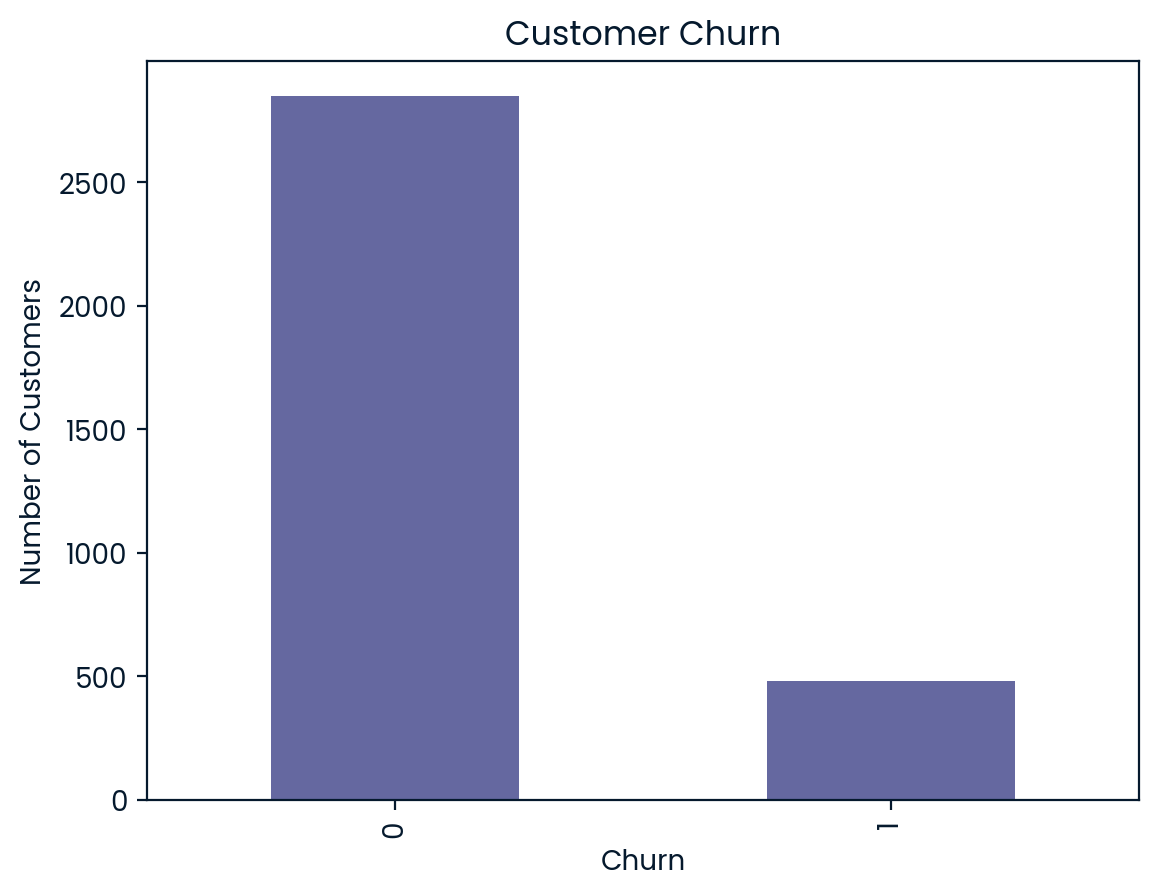

In [28]:
import matplotlib.pyplot as plt

telecom["churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

Customer Churn

The chart shows the number of customers who churned compared with those who remained with the company. Most customers did not churn, while a smaller proportion of customers left the service. This shows that customer churn is present in the dataset and provides a useful starting point for investigating which customer characteristics are associated with churn.


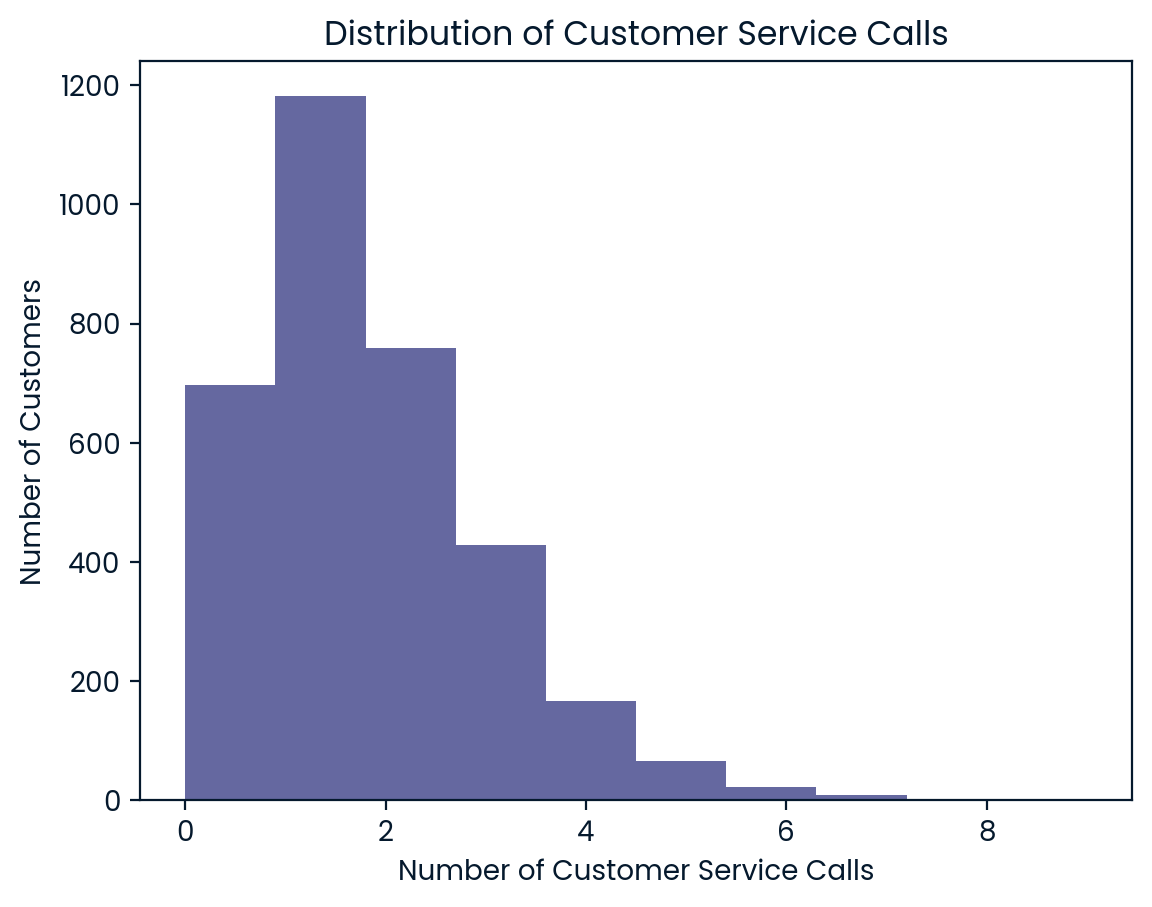

In [29]:
telecom["customer_service_calls"].plot(kind="hist", bins=10)

plt.title("Distribution of Customer Service Calls")
plt.xlabel("Number of Customer Service Calls")
plt.ylabel("Number of Customers")
plt.show()

Customer Service Calls

The histogram shows the distribution of customer service calls made by customers. Most customers made a relatively small number of calls, while fewer customers made a higher number of calls. This variable is useful for further analysis because repeated contact with customer service may be related to customer churn.


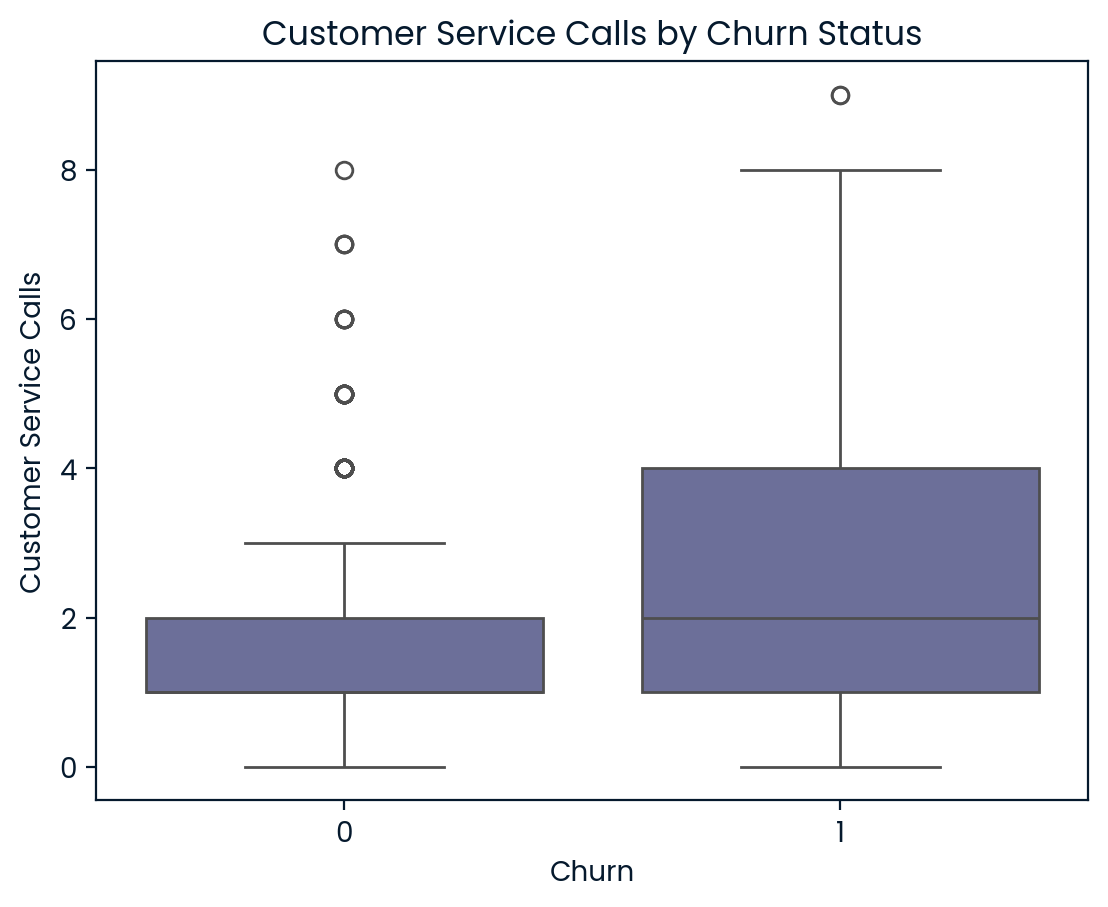

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="churn", y="customer_service_calls", data=telecom)

plt.title("Customer Service Calls by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Customer Service Calls")
plt.show()

Relationship Between Customer Service Calls and Churn

The box plot compares the number of customer service calls for customers who churned and those who did not. It allows the distribution of customer service calls to be compared across the two churn groups. Customers with higher levels of customer service contact can then be considered as a group for further investigation and retention activity.


In [31]:
churn_rate = telecom["churn"].mean() * 100

print(f"Current churn rate: {churn_rate:.2f}%")

Current churn rate: 14.49%


Business Metric

The main metric for monitoring the business problem is the customer churn rate.

The churn rate is calculated as:

Churn Rate = Number of Churned Customers / Total Number of Customers × 100

This metric shows the proportion of customers who have left the service. Fit.ly can monitor the churn rate regularly to identify whether customer retention is improving or deteriorating.

The current dataset provides a baseline churn rate that can be used for comparison with future periods.


Final Summary and Recommendations

The analysis shows that customer churn is an important business issue for Fit.ly. In the current dataset, 14.49% of customers have churned, providing a baseline that Fit.ly can use when monitoring customer retention over time.

The exploratory analysis also shows that customer service activity varies across customers, and the relationship between customer service calls and churn is worth monitoring. Customers with higher levels of customer service contact can be investigated further as a potential higher-risk group.

Fit.ly should monitor the churn rate regularly and compare it with this 14.49% baseline. The business should also monitor customer service interactions and investigate customers with repeated service contacts as part of its retention strategy.

Future analysis could examine other customer characteristics, such as international plan usage, calling activity, and account length, to identify additional patterns associated with churn. Any retention strategy should then be evaluated by tracking whether the churn rate changes over time.

Conclusion

The analysis provides Fit.ly with a clear baseline for customer churn and identifies customer service activity as an area for further investigation. Regular monitoring of the churn rate, combined with deeper analysis of customer behaviour, can help the business identify potential retention opportunities.
